🤔 내 맘대로 생각해보는 대략 순서

1. 데이터 가져와
2. 데이터 훑어봐
3. 데이터 구조 파악해
4. 대충 원하는 가설 세워봐
5. eda해 시각화해
6. 통계분석을 위한 전처리해
7. 통계 분석해
8. 머신러닝을 위한 전처리해
9. 머신러닝 분석해

## 0️⃣ 빠른 데이터 훑기 (1~3단계)


[메타데이터](https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html)

## 🏡 California Housing Dataset (housing.csv)

| 컬럼명 | 설명 | 단위 / 특징 |
|:--|:--|:--|
| **longitude** | 경도 | 실수(지리좌표, 서쪽 방향으로 값이 감소) |
| **latitude** | 위도 | 실수(지리좌표, 북쪽 방향으로 값이 증가) |
| **housing_median_age** | 주택의 중간 연식 | 년(years) |
| **total_rooms** | 블록 그룹 내 총 방 수 | 개수(count) |
| **total_bedrooms** | 블록 그룹 내 총 침실 수 | 개수(count) |
| **population** | 블록 그룹의 총 인구 수 | 명(persons) |
| **households** | 가구 수 | 가구 수(households) |
| **median_income** | 블록 그룹의 중간 소득 (Median Income) | 10,000달러 단위 |
| **median_house_value** | 블록 그룹의 중간 주택 가격 (Target Variable) | 달러(USD) |
| **ocean_proximity** | 해안 근접 정도 범주형 변수 | 범주형 |


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("data/housing.csv")

In [3]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [7]:
df.shape

(20640, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

🤔 

- 'ocean_proximity'만 범주형 데이터고 나머지는 수치형 데이터군.
  - 'ocean_proximity' 값의 데이터를 찾아봐야겠다.
    - `INLAND`: 내륙 지역
  
    - `<1H OCEAN`: 해안까지 1시간 이내 거리
  
    - `NEAR BAY`: 샌프란시스코만(SF Bay) 근처

    - `NEAR OCEAN`: 태평양 연안 직접 인접 지역

    - `ISLAND`: 섬 지역

  - 이거 라벨링? 원-핫인코딩? 고민 해보자
    - GPT "지금은 EDA 먼저, 원-핫 인코딩은 나중에" "인코딩은 모델에 입력하기 위한 변환 과정이지,  데이터 이해를 돕는 시각화를 위한 단계가 아니야."


In [9]:
# 중복 확인
dups = df.duplicated().sum()
print(f"\n[중복 행 수] {dups}")

# 결측치 확인
print("\n[결측치 개수]")
print(df.isna().sum())


[중복 행 수] 0

[결측치 개수]
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


🤔

- 'total_bedrooms'는 207개의 결측치가 있네?
  - 대체를 할까, 삭제를 할까? --> 1%니까 그냥 삭제하자..

In [19]:
# 'total_bedrooms' 가 null인 행들의 요약
df[df['total_bedrooms'].isna() == True].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,207.000000,207.000000,207.000000,207.000000,0.0,207.000000,207.000000,207.000000,207.000000
mean,-119.472560,35.497633,29.270531,2562.603865,NaN,1477.772947,510.024155,3.822244,206007.280193
std,2.001424,2.097298,11.964927,1787.269789,NaN,1057.448212,386.120704,1.955595,111638.214545
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.810000,33.970000,19.000000,1307.500000,NaN,781.000000,258.000000,2.564150,128750.000000
50%,-118.490000,34.200000,30.000000,2155.000000,NaN,1217.000000,427.000000,3.411500,175000.000000
75%,-117.985000,37.495000,38.000000,3465.000000,NaN,1889.500000,628.000000,4.615750,267700.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


In [20]:
# dropna로 삭제
df = df.dropna()

# 결측치 확인
print("\n[결측치 개수]")
print(df.isna().sum())


[결측치 개수]
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


🤔 결측치 삭제 완료

## 1️⃣ EDA + 가설 탐색 (4~5단계)

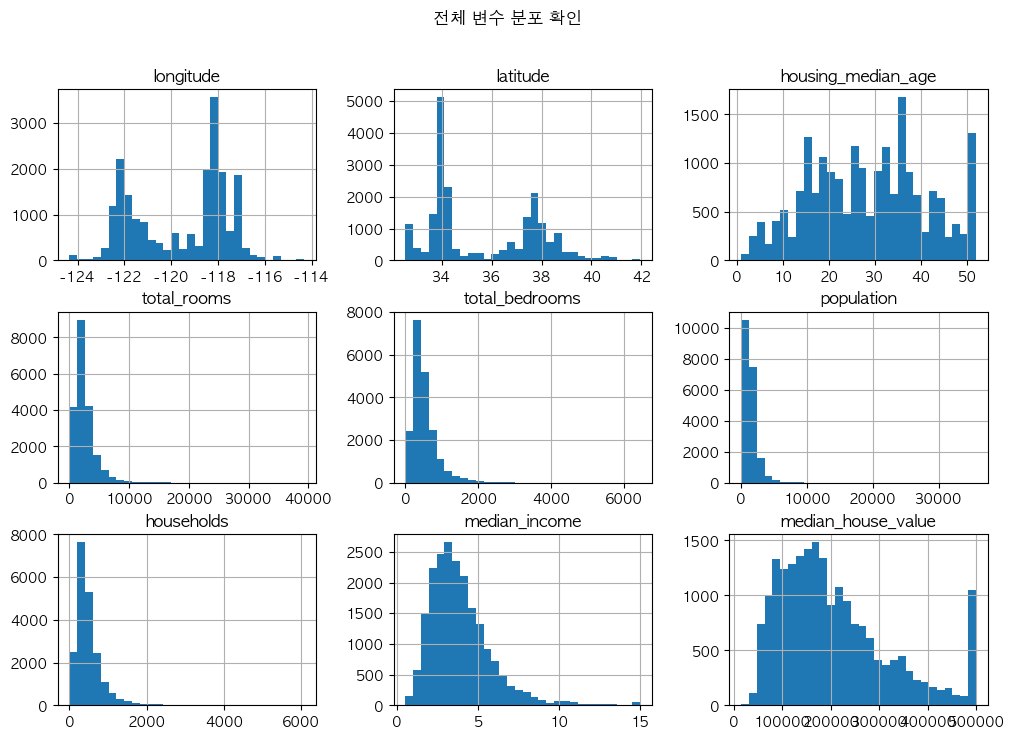

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

df.hist(bins=30, figsize=(12,8))
plt.suptitle("전체 변수 분포 확인")
plt.show()

🤔

- 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income' 은 롱테일 그래프네.
  
- 'median_house_value'는 왜 오른쪽 극값이 높지?
  
- 'median_house_value'는 스케일이 완전 큼. 스케일링 필요하겠다.

### 상관관계 분석

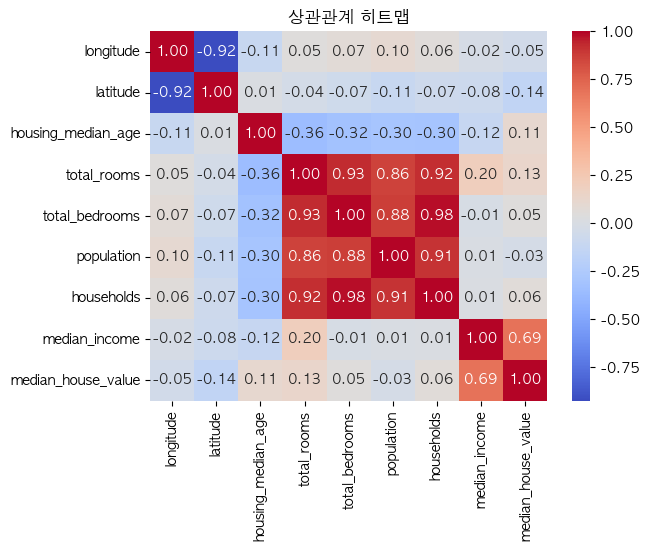

In [26]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")  # 시각화
plt.title("상관관계 히트맵")
plt.show()

🤔

- `'longitude'`, `'latitude'` 얘네의 상관관계는 의미 없음.
  
- `'total_rooms'`, `'total_bedrooms'`, `'population'`, `'households'`의 강한 양의 상관관계는 상식으로 당연한 내용.

  - 가구수 많은 곳이 거주민도 많고, 방도 많고, 안방도 많은 거지 
  - 다중공선성 check 필요
  
- `'median_income'`과 `'median_house_value'` 또한, 벌이가 많은 사람이 비싼 집에 살겠지

In [38]:

# 다중공선성
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["total_rooms", "total_bedrooms", "population", 'households']]
X = sm.add_constant(X) # 상수항 추가 -> 없으면 부정확할 수 있음 (없으면 회귀직선이 반드시 원점을 지나야 하는 특수한 상황이어야 하기 때문)
# VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)
    


         variable        VIF
0           const   2.736472
1     total_rooms   7.863368
2  total_bedrooms  30.365096
3      population   6.011598
4      households  32.885999


🤔

- `total_bedrooms`, `households` 심각한 다중공선성
  
- `total_rooms`, `population` 약한 다중공선성

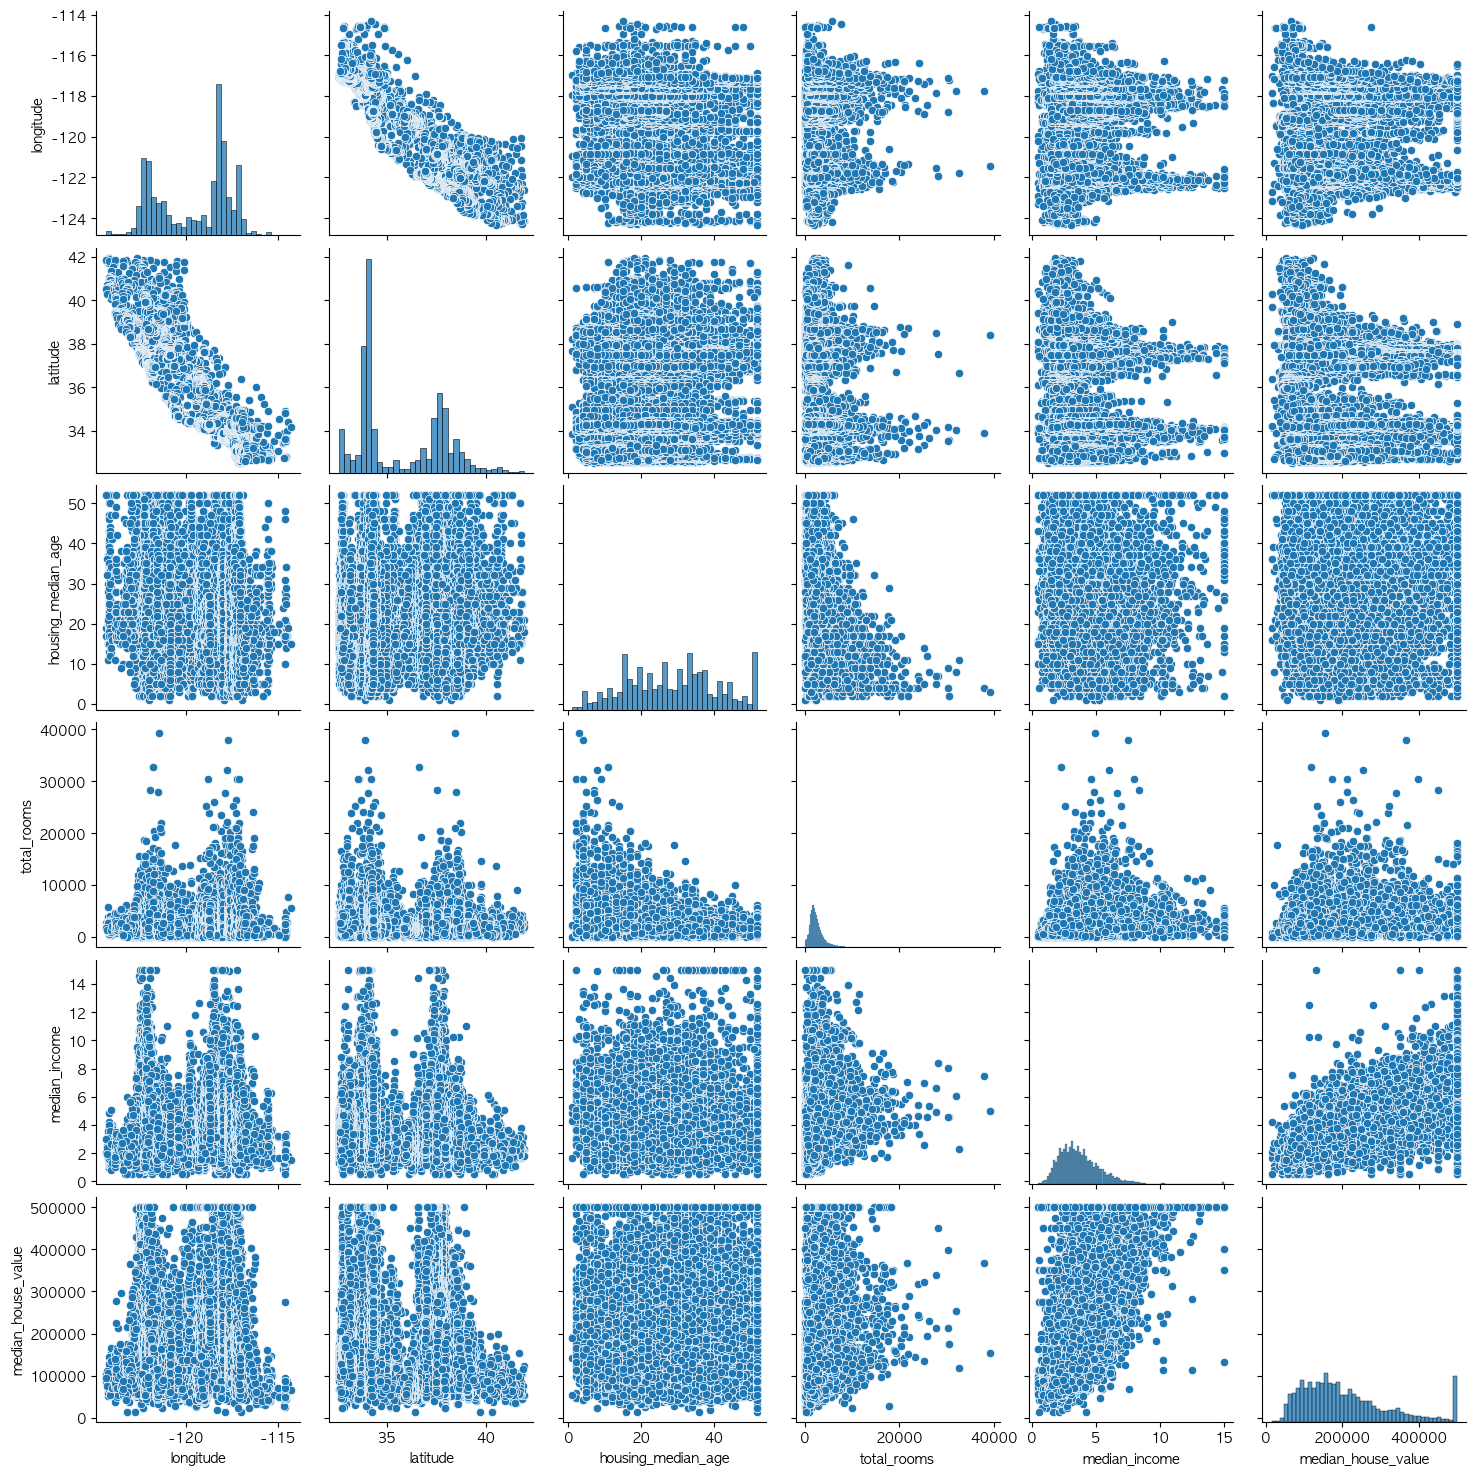

In [35]:
numeric_df = df.drop(['ocean_proximity', 'total_bedrooms', 'population', 'households'], axis = 1)
numeric_features = ["longitude", "latitude", "housing_median_age", "total_rooms", "median_income"]

sns.pairplot(numeric_df)
plt.show()

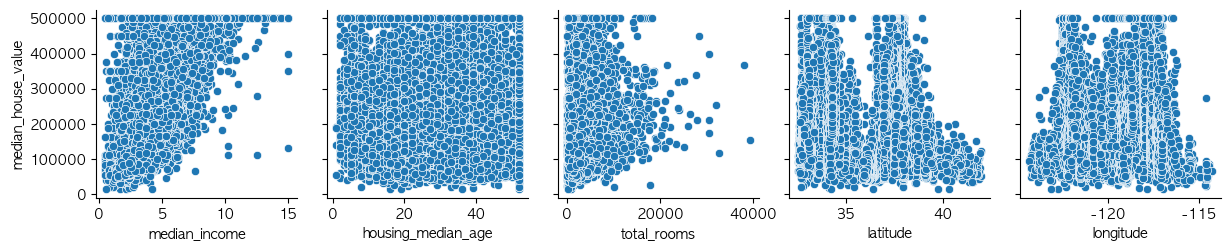

In [37]:
# 주택가격과의 관계 (산점도)
num_features = ["median_income", "housing_median_age", "total_rooms", "latitude", "longitude"]
sns.pairplot(df, x_vars=num_features, y_vars=["median_house_value"])
plt.show()

🤔

- 1번 산점도
  - 소득이 높을수록 집값이 비싸군.
  
- 2번 산점도
  - 관계 없음
  
- 3번 산점도
  - 관계 없음

- 4번 산점도
  - 오른쪽보다 왼쪽에 비싼 집이 많음 (약한 상관관계)
  - 위도가 낮을 수록 집값이 높다 -> 남쪽일수록 집값이 높다
  
- 5번 산점도
  - 오른쪽보다 왼쪽에 비싼 집이 많음 (약한 상관관계)
  - 경도가 낮을 수록 집값이 높다 -> 서쪽일수록 집값이 높다

내가 세운 가설 -> **남서쪽일수록 집값이 높다**

In [39]:
# 다중회귀

X = df[["longitude", "latitude"]] 
y = df["median_house_value"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     3263.
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               0.00
Time:                        02:24:40   Log-Likelihood:            -2.6434e+05
No. Observations:               20433   AIC:                         5.287e+05
Df Residuals:                   20430   BIC:                         5.287e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.822e+06   8.25e+04    -70.546      0.0

🤔

- 모형 설명력

## 📊 OLS 회귀 결과 요약 — “남서쪽일수록 집값이 높다” 가설 검정

| 항목 | 값 | 해석 |
|------|------|------|
| **모델식** | `median_house_value ~ longitude + latitude` | 경도·위도로 주택가격 설명 시도 |
| **R-squared** | 0.242 | 모델이 전체 주택가격 변동의 약 24.2%를 설명함 |
| **Prob (F-statistic)** | 0.000 | 전체 모델이 통계적으로 유의함 |
| **longitude 계수** | -7.11e+04 | 경도 1 증가(동쪽 이동) 시 집값 약 **71,000달러 하락** → 서쪽(해안가)일수록 집값 높음 |
| **latitude 계수** | -6.95e+04 | 위도 1 증가(북쪽 이동) 시 집값 약 **69,000달러 하락** → 남쪽(로스앤젤레스 방향)일수록 집값 높음 |
| **P>\|t\| (각 변수)** | 0.000 | 두 변수 모두 통계적으로 유의 (p < 0.05) |

---

### ✅ 해석 요약
- 경도와 위도 모두 **유의미한 음의 관계**를 가짐 → 남서쪽일수록 집값이 높음
 
- 단, **설명력(R²=0.24)** 은 낮아 지리적 요인만으로는 집값의 일부만 설명함
  
- 따라서 이후 단계에서는 **소득(`median_income`)** 등 사회경제적 변수 추가 필요
